# AICE Associate 대비 실습 과정 — 1회차
## AI / ML / DL 개요와 데이터 획득하기

> **과정 구성**: 총 8회 × 3시간, 실습 위주  
> **대상**: Python 기초 문법을 아는 비전공자 ~ 준전공자  
> **환경**: Google Colab 또는 로컬 Jupyter (Python 3.9+, pandas, scikit-learn)

### 전체 커리큘럼

| 회차 | 주제 | 핵심 키워드 |
|:---:|------|------------|
| **1** | **AI/ML/DL 개요, 데이터 획득하기** | AI ⊃ ML ⊃ DL, 지도/비지도, `read_csv`, `read_excel`, `to_csv` |
| 2 | 데이터 구조 확인하기, 기초 데이터 다루기 | `info`, `describe`, `loc/iloc`, 필터링, 정렬, `groupby`, `merge` |
| 3 | 데이터 이해하기 (EDA) | 분포, 상관관계, `matplotlib`, `seaborn`, 가설 검증 |
| 4 | 데이터 전처리하기 | 결측치, 이상치, 구간화, 인코딩, 스케일링, `train_test_split` |
| 5 | AI 모델링 필수 개념, 지도학습 I | 과적합, 평가지표, 선형회귀, 로지스틱 회귀 |
| 6 | 지도학습 II | 의사결정나무, 앙상블, 랜덤포레스트, 그라디언트부스팅 |
| 7 | 인공신경망, 심층신경망, 딥러닝 프레임워크 | 퍼셉트론, 활성화함수, Keras `Sequential`, `EarlyStopping` |
| 8 | 비지도학습, 모델 성능 향상시키기 | K-Means, PCA, 교차검증, 하이퍼파라미터 튜닝, 모의고사 |

### 오늘의 학습 목표

1. AI, 머신러닝, 딥러닝의 관계와 차이를 **한 문장으로** 설명할 수 있다.
2. 지도학습 / 비지도학습 / 강화학습을 구분하고, 회귀와 분류 문제를 구별할 수 있다.
3. AI 모델링의 전체 흐름(데이터 획득 → 전처리 → 모델링 → 평가)을 그릴 수 있다.
4. CSV / Excel / JSON / URL / 내장 데이터셋에서 `pandas` 로 데이터를 읽어올 수 있다.
5. 읽기 옵션(`sep`, `encoding`, `header`, `index_col`, `usecols`, `na_values` …)을 상황에 맞게 쓸 수 있다.
6. 데이터를 파일로 저장하고, 파일 입출력에서 자주 나는 오류를 스스로 해결할 수 있다.

### 시간 계획 (180분)

| 시간 | 내용 |
|------|------|
| 00:00 ~ 00:15 | 0. 실습 환경 준비 |
| 00:15 ~ 00:55 | 1. AI / ML / DL 정의 |
| 00:55 ~ 01:05 | 휴식 |
| 01:05 ~ 02:25 | 2. 데이터 획득하기 |
| 02:25 ~ 02:35 | 휴식 |
| 02:35 ~ 03:00 | 3. 종합 실습 + 정리 |

---
## 0. 실습 환경 준비

### 0.1 Colab vs 로컬

| 항목 | Google Colab | 로컬 Jupyter |
|------|--------------|--------------|
| 설치 | 불필요 (브라우저, 모두 기본 설치됨) | Python + `pip install numpy pandas matplotlib seaborn scikit-learn tensorflow openpyxl` |
| 파일 위치 | `/content/` (세션 종료 시 삭제) | 노트북이 있는 폴더 |
| 한글 폰트 | 나눔폰트 설치 + 런타임 재시작 필요 | Mac: AppleGothic, Windows: Malgun Gothic |
| AICE 시험 환경 | 시험도 **웹 브라우저 기반 Jupyter** 로 진행 | — |

#### 시험에서 사용하는 라이브러리

| 라이브러리 | 용도 | 시험 출제 영역 |
|------|------|------|
| `numpy` | 수치 배열 연산 | 전 영역 기반 |
| `pandas` | 표 데이터 읽기·가공 | 데이터 획득, 구조 확인, 전처리 |
| `matplotlib` | 기본 시각화 | 데이터 이해(EDA) |
| `seaborn` | 통계 시각화 (`histplot`, `boxplot`, `heatmap`, `countplot`) | 데이터 이해(EDA) |
| `scikit-learn` | 전처리, 머신러닝 모델, 평가지표 | 전처리, 모델링, 평가 |
| `tensorflow` / `keras` | 딥러닝(DNN) 모델 | 모델링(딥러닝 문항) |

> 💡 AICE Associate 시험은 인터넷 검색이 허용되지 않지만, **Jupyter 의 자동완성(Tab)과 `?` 도움말은 사용 가능**합니다. 이번 과정에서는 도움말을 적극 활용하는 습관을 들입니다.

In [1]:
# 실습에 사용하는 라이브러리를 불러오고 버전을 확인한다.
# 버전이 달라도 이 과정의 코드는 대부분 그대로 동작한다.
import sys
import os
import json

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

print(f"Python       : {sys.version.split()[0]}")
print(f"numpy        : {np.__version__}")
print(f"pandas       : {pd.__version__}")
print(f"matplotlib   : {matplotlib.__version__}")
print(f"seaborn      : {sns.__version__}")
print(f"scikit-learn : {sklearn.__version__}")

Python       : 3.11.4
numpy        : 1.26.4
pandas       : 2.2.1
matplotlib   : 3.8.3
seaborn      : 0.13.2
scikit-learn : 1.5.0


In [2]:
# TensorFlow 는 크기가 커서 import 에 수 초가 걸린다. 설치가 안 되어 있으면 안내만 출력한다.
# 로컬 설치: pip install tensorflow   (Apple Silicon Mac: pip install tensorflow-macos)
try:
  import tensorflow as tf
  from tensorflow import keras
  print(f"tensorflow   : {tf.__version__}")
  print(f"keras        : {getattr(keras, '__version__', '(tensorflow 내장 keras)')}")
  print(f"GPU 사용 가능 : {len(tf.config.list_physical_devices('GPU')) > 0}")
except ImportError:
  print("tensorflow 미설치 - 7회차(딥러닝) 전까지 설치하면 됩니다.")

tensorflow   : 2.15.0
keras        : (tensorflow 내장 keras)
GPU 사용 가능 : True


In [3]:
# 한글 폰트 설정: 환경에 맞는 폰트를 자동으로 고른다.
# Colab 이라면 아래 주석의 명령을 먼저 실행하고 런타임을 재시작해야 한다.
#   !apt-get -qq install fonts-nanum
#   !rm -rf ~/.cache/matplotlib
from matplotlib import font_manager


def set_korean_font() -> str:
  candidates = ["AppleGothic", "Malgun Gothic", "NanumGothic", "NanumBarunGothic"]
  installed = {f.name for f in font_manager.fontManager.ttflist}
  for name in candidates:
    if name in installed:
      plt.rcParams["font.family"] = name
      plt.rcParams["axes.unicode_minus"] = False
      return name
  plt.rcParams["axes.unicode_minus"] = False
  return "(한글 폰트 없음 - 그래프의 한글이 깨질 수 있음)"


print("적용된 폰트:", set_korean_font())

적용된 폰트: AppleGothic


In [4]:
# 실습 파일을 저장할 폴더를 만든다. 이미 있으면 그대로 사용한다.
DATA_DIR = "data"
os.makedirs(DATA_DIR, exist_ok=True)

print("현재 작업 폴더:", os.getcwd())
print("data 폴더 존재 여부:", os.path.isdir(DATA_DIR))

현재 작업 폴더: /Users/eunbumkim/Desktop/02_프로젝트_코드/aice_test/aice_course
data 폴더 존재 여부: True


---
## 1. AI / ML / DL 정의

### 1.1 세 용어의 관계

#### 한 줄 정의

| 용어 | 한 줄 정의 |
|------|-----------|
| **AI (인공지능)** | 사람처럼 판단·예측·행동하는 컴퓨터 프로그램 전체 |
| **ML (머신러닝)** | 규칙을 사람이 코딩하지 않고, **데이터에서 규칙을 스스로 찾게** 하는 AI 의 한 방법 |
| **DL (딥러닝)** | 여러 층의 **인공신경망**으로 규칙을 찾는 머신러닝의 한 방법 |

#### 직관적 설명

```
┌──────────────────────────────── AI ────────────────────────────────┐
│  규칙 기반 시스템(if-else 전문가 시스템), 탐색 알고리즘 …             │
│   ┌────────────────────────── ML ───────────────────────────┐      │
│   │  선형회귀, 로지스틱회귀, 의사결정나무, 랜덤포레스트, SVM … │      │
│   │   ┌───────────────────── DL ─────────────────────┐       │      │
│   │   │  DNN, CNN(이미지), RNN/LSTM(시계열), Transformer │       │      │
│   │   └──────────────────────────────────────────────┘       │      │
│   └──────────────────────────────────────────────────────────┘      │
└─────────────────────────────────────────────────────────────────────┘
```

- **AI 가 가장 큰 개념**이고, ML 은 그 안의 "데이터로 학습하는" 부분, DL 은 ML 안에서 "신경망을 깊게 쌓은" 부분입니다.
- 딥러닝도 머신러닝이므로, 이 과정에서 배우는 **전처리 · 평가 방법은 딥러닝에도 그대로** 적용됩니다.

### 1.2 전통 프로그래밍 vs 머신러닝

| 항목 | 전통 프로그래밍 | 머신러닝 |
|------|----------------|---------|
| 입력 | **규칙 + 데이터** | **데이터 + 정답** |
| 출력 | 결과 | **규칙(모델)** |
| 예시 | 섭씨 → 화씨 공식을 코드로 작성 | 섭씨·화씨 쌍을 보여주고 공식을 찾게 함 |
| 언제 유리 | 규칙이 명확하고 단순할 때 | 규칙이 복잡하거나 사람이 설명하기 어려울 때 (이미지, 언어, 고객 이탈…) |

아래 실습에서 **같은 문제를 두 방식으로** 풀어 봅니다.

In [5]:
# [전통 프로그래밍] 사람이 규칙(공식)을 직접 코딩한다.
def celsius_to_fahrenheit(c: float) -> float:
  return c * 1.8 + 32


for c in [0, 10, 25, 100]:
  print(f"{c:>4}°C -> {celsius_to_fahrenheit(c):.1f}°F")

   0°C -> 32.0°F
  10°C -> 50.0°F
  25°C -> 77.0°F
 100°C -> 212.0°F


In [6]:
# [머신러닝] 규칙은 모른 채, 데이터(입력 X, 정답 y)만 주고 규칙을 찾게 한다.
from sklearn.linear_model import LinearRegression

X = np.array([[-10], [0], [10], [20], [30], [40]])   # 입력: 섭씨 (2차원 배열이어야 함!)
y = np.array([14, 32, 50, 68, 86, 104])              # 정답: 화씨

model = LinearRegression()
model.fit(X, y)                                       # 학습: 데이터에서 규칙 찾기

print(f"찾아낸 규칙: 화씨 = {model.coef_[0]:.2f} × 섭씨 + {model.intercept_:.2f}")
print(f"25°C 예측  : {model.predict([[25]])[0]:.1f}°F  (정답 77.0)")

찾아낸 규칙: 화씨 = 1.80 × 섭씨 + 32.00
25°C 예측  : 77.0°F  (정답 77.0)


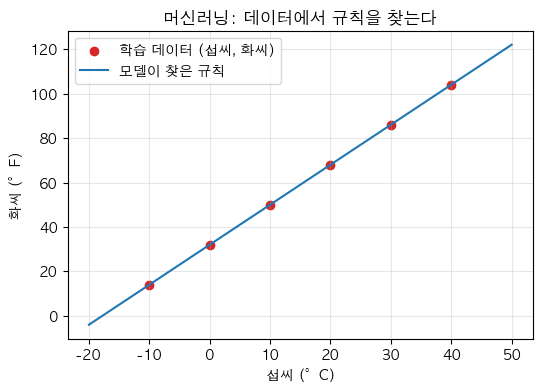

In [7]:
# 학습된 규칙을 그림으로 확인한다.
x_line = np.linspace(-20, 50, 100).reshape(-1, 1)

plt.figure(figsize=(6, 4))
plt.scatter(X, y, color="tab:red", label="학습 데이터 (섭씨, 화씨)")
plt.plot(x_line, model.predict(x_line), label="모델이 찾은 규칙")
plt.xlabel("섭씨 (°C)")
plt.ylabel("화씨 (°F)")
plt.title("머신러닝: 데이터에서 규칙을 찾는다")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

> **📌 핵심**: 머신러닝의 `fit()` 은 "데이터를 보고 규칙(파라미터)을 찾아라", `predict()` 는 "찾은 규칙으로 새 입력의 답을 내라" 입니다.  
> 이 두 메서드 이름은 scikit-learn 의 **모든 모델에서 동일**합니다. (5회차에서 자세히)

### 1.3 머신러닝의 세 가지 종류

| 종류 | 정답(label) 유무 | 목적 | 대표 알고리즘 | 예시 |
|------|:---:|------|------|------|
| **지도학습**<br>(Supervised) | **있음** | 정답을 맞히는 규칙 학습 | 선형회귀, 로지스틱회귀, 의사결정나무, 랜덤포레스트, 신경망 | 집값 예측, 이탈 여부 분류 |
| **비지도학습**<br>(Unsupervised) | **없음** | 데이터의 숨은 구조 발견 | K-Means, 계층 군집, PCA | 고객 세분화, 차원 축소 |
| **강화학습**<br>(Reinforcement) | 보상(reward) | 시행착오로 최적 행동 학습 | Q-Learning, DQN | 게임 AI, 로봇 제어 |

#### 지도학습은 다시 두 가지로 나뉜다

| 구분 | **회귀 (Regression)** | **분류 (Classification)** |
|------|------|------|
| 정답 y 의 형태 | **연속된 숫자** (집값, 온도, 매출) | **범주** (Yes/No, 고양이/개, 등급 A/B/C) |
| 질문 형태 | "얼마?" "몇 개?" | "어느 쪽?" "무엇?" |
| 평가 지표 | MAE, MSE, RMSE, R² | 정확도, 정밀도, 재현율, F1 |
| 대표 모델 | `LinearRegression` | `LogisticRegression` (이름에 회귀가 있지만 **분류** 모델!) |

> **시험 팁**: 문제에서 예측 대상 컬럼(y)의 값이 **숫자면 회귀, 카테고리면 분류**. 이것만 정확히 판단해도 모델·평가지표 선택이 결정됩니다.

In [8]:
# 같은 고객 데이터에서 "회귀 문제"와 "분류 문제"를 정의해 본다.
# y 의 형태만 다를 뿐, X(입력)는 동일할 수 있다.
customers = pd.DataFrame({
  "나이": [25, 34, 45, 52, 23, 38],
  "가입개월수": [3, 24, 60, 84, 1, 36],
  "월요금": [35000, 55000, 89000, 79000, 29000, 65000],   # 회귀 타깃 후보
  "이탈여부": ["Yes", "No", "No", "No", "Yes", "No"],              # 분류 타깃 후보
})
customers

,나이,가입개월수,월요금,이탈여부
0,25,3,35000,Yes
1,34,24,55000,No
2,45,60,89000,No
3,52,84,79000,No
4,23,1,29000,Yes
5,38,36,65000,No


In [9]:
# 회귀 문제: 나이·가입기간으로 월 요금(연속값)을 예측
X = customers[["나이", "가입개월수"]]
y_reg = customers["월요금"]
print("회귀 타깃 dtype :", y_reg.dtype, "-> 숫자이므로 회귀")

# 분류 문제: 나이·가입기간으로 이탈 여부(범주)를 예측
y_clf = customers["이탈여부"]
print("분류 타깃 dtype :", y_clf.dtype, "-> 문자열(범주)이므로 분류")
print("분류 타깃 종류  :", y_clf.unique(), "-> 클래스가 2개이므로 이진 분류")

회귀 타깃 dtype : int64 -> 숫자이므로 회귀
분류 타깃 dtype : object -> 문자열(범주)이므로 분류
분류 타깃 종류  : ['Yes' 'No'] -> 클래스가 2개이므로 이진 분류


### 1.4 딥러닝은 언제 쓰는가

| 항목 | 머신러닝 (전통 ML) | 딥러닝 |
|------|------|------|
| 특징(feature) 추출 | **사람이** 컬럼을 설계 | **모델이** 원시 데이터에서 스스로 추출 |
| 잘 맞는 데이터 | 표(테이블) 형태, 수천 ~ 수십만 행 | 이미지, 음성, 텍스트, 대용량 |
| 필요한 데이터 양 | 비교적 적음 | 많음 |
| 학습 시간 / 자원 | 짧음, CPU 로 충분 | 김, GPU 권장 |
| 해석 가능성 | 높음 (트리, 회귀 계수) | 낮음 (블랙박스) |
| 라이브러리 | scikit-learn | TensorFlow/Keras, PyTorch |

> AICE Associate 시험은 **테이블 데이터** 를 다루므로 scikit-learn 모델이 중심이고, 마지막에 Keras 로 간단한 신경망(DNN)을 만드는 문항이 나옵니다. (7회차)

### 1.5 AI 모델링의 전체 흐름

AICE 시험 문항은 아래 순서 그대로 출제됩니다. 이 과정의 회차도 이 순서를 따릅니다.

```
① 데이터 획득  →  ② 구조 확인  →  ③ 탐색(EDA)  →  ④ 전처리  →  ⑤ 모델링  →  ⑥ 평가  →  ⑦ 성능 개선
   read_csv       info/describe   시각화/상관      결측/인코딩    fit          predict/score   튜닝/앙상블
   (1회차)        (2회차)          (3회차)          (4회차)       (5~7회차)    (5~7회차)       (8회차)
```

아래는 **전체 흐름을 5분 만에 훑는 맛보기**입니다. 지금은 코드를 이해하지 못해도 괜찮습니다. 흐름만 눈에 익히세요.

In [10]:
# ===== AI 모델링 전체 흐름 맛보기 (붓꽃 품종 분류) =====
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# ① 데이터 획득
# 내장 데이터셋은 컬럼명이 영어로 고정되어 있다. 의미를 알기 쉽게 한글로 바꿔서 진행한다.
#   sepal length/width (cm) = 꽃받침 길이/너비, petal length/width (cm) = 꽃잎 길이/너비
iris = load_iris()
df = pd.DataFrame(iris.data, columns=["꽃받침길이", "꽃받침너비", "꽃잎길이", "꽃잎너비"])
df["품종"] = iris.target          # 0=setosa, 1=versicolor, 2=virginica

# ② 구조 확인
print("데이터 크기:", df.shape)
display(df.head(3))

# ③ 탐색 (간단히 클래스 분포만)
print("품종별 개수:\n", df["품종"].value_counts().to_dict())

# ④ 전처리: 입력 X 와 정답 y 분리, 학습용/평가용 분할
X = df.drop("품종", axis=1)
y = df["품종"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# ⑤ 모델링: 학습
model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)

# ⑥ 평가: 예측 후 정확도
y_pred = model.predict(X_test)
print(f"\n테스트 정확도: {accuracy_score(y_test, y_pred):.3f}")

데이터 크기: (150, 5)


,꽃받침길이,꽃받침너비,꽃잎길이,꽃잎너비,품종
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0


품종별 개수:
 {0: 50, 1: 50, 2: 50}

테스트 정확도: 1.000


### 📝 시험 출제 포인트 (1장)

- AICE Associate 는 **실기 시험** 이라 "AI 의 정의" 를 직접 묻지는 않지만, **문제 지문을 읽고 회귀인지 분류인지 판단** 하는 능력이 모든 모델링 문항의 출발점입니다.
- `fit()` → `predict()` 흐름과, 학습용/평가용 데이터를 나누는 이유(**과적합 확인**)는 매 시험 출제됩니다. (4~5회차)
- `LogisticRegression` 은 이름과 달리 **분류** 모델입니다.

### ⚠️ 자주 하는 실수 (1장)

- **"y 가 0/1 숫자니까 회귀"**: 0/1 은 범주를 숫자로 표현한 것이므로 **분류** 입니다. 값의 의미가 "양(quantity)" 인지 "종류(category)" 인지로 판단합니다.
- **입력 X 를 1차원으로 넣음**: scikit-learn 의 `fit(X, y)` 에서 X 는 항상 **2차원** (행=샘플, 열=특징) 이어야 합니다. 특징이 1개여도 `X.reshape(-1, 1)` 또는 `df[["col"]]` (대괄호 두 개) 로 2차원을 유지합니다.
- **딥러닝이 항상 좋다는 생각**: 테이블 데이터에서는 랜덤포레스트·그라디언트부스팅이 신경망보다 좋은 경우가 매우 흔합니다.

---
## 2. 데이터 획득하기

### 2.1 데이터는 어디서 오는가

| 출처 | 형태 | pandas 함수 | 실무/시험 빈도 |
|------|------|-------------|:---:|
| 파일 | **CSV** (`.csv`, `.txt`) | `pd.read_csv()` | ★★★★★ |
| 파일 | Excel (`.xlsx`) | `pd.read_excel()` | ★★★ |
| 파일 | JSON (`.json`) | `pd.read_json()` | ★★ |
| 웹 | URL 의 CSV | `pd.read_csv("https://…")` | ★★ |
| 라이브러리 내장 | scikit-learn, seaborn 샘플 | `load_iris()`, `sns.load_dataset()` | ★★★ (연습용) |
| 데이터베이스 | SQL | `pd.read_sql()` | ★ (시험 미출제) |
| 직접 생성 | dict / list / numpy | `pd.DataFrame()` | ★★★ |

> AICE 시험에서는 **문제에서 지정한 파일명과 변수명을 정확히 사용** 해야 합니다. 예: `df = pd.read_csv("data.csv")` 처럼 변수명이 `df` 로 지정되면 이후 문항 채점이 이 변수를 기준으로 이뤄집니다.

### 2.2 실습용 파일 만들기

읽기 연습을 하려면 먼저 파일이 있어야 합니다. 아래 셀은 **가상의 통신사 고객 데이터** 를 만들어 여러 형식으로 저장합니다.  
(생성 코드 자체는 지금 이해하지 않아도 됩니다. 실행만 하세요.)

In [11]:
# ===== 실습용 가상 데이터 생성 (실행만 하면 됩니다) =====
rng = np.random.default_rng(42)
n = 300

regions = ["서울", "경기", "부산", "대구", "기타"]
plans = ["5G", "LTE", "3G"]

# 데이터 사용량: 일반 사용자(90%)는 평균 12GB·표준편차 4GB 의 종 모양(정규분포)으로,
#               헤비 유저(10%)는 30~70GB 사이에서 고르게(균등분포) 만든다.
#               -> 대부분은 10GB 안팎이고 소수만 큰 값을 가지는, 오른쪽 꼬리가 긴 분포가 된다.
is_heavy = rng.random(n) < 0.10                                    # 행마다 10% 확률로 헤비 유저
usage = np.where(is_heavy, rng.uniform(30, 70, size=n), rng.normal(12, 4, size=n))
usage = np.clip(usage, 0.5, None)                                  # 음수 방지: 최소 0.5GB

customers = pd.DataFrame({
  "고객ID": [f"C{i:04d}" for i in range(1, n + 1)],
  "성별": rng.choice(["M", "F"], size=n),
  "나이": rng.integers(19, 70, size=n).astype(float),
  "지역": rng.choice(regions, size=n, p=[0.35, 0.3, 0.15, 0.1, 0.1]),
  "우편번호": [f"{z:05d}" for z in rng.integers(1000, 63999, size=n)],
  "요금제": rng.choice(plans, size=n, p=[0.5, 0.4, 0.1]),
  "월요금": rng.choice([29000, 35000, 45000, 55000, 65000, 79000, 89000], size=n).astype(float),
  "데이터사용량": np.round(usage, 1),
  "가입일": pd.to_datetime("2019-01-01") + pd.to_timedelta(rng.integers(0, 2000, size=n), unit="D"),
})
customers["가입개월수"] = ((pd.to_datetime("2024-12-31") - customers["가입일"]).dt.days // 30)
churn_prob = 0.15 + 0.25 * (customers["가입개월수"] < 12) + 0.1 * (customers["요금제"] == "3G")
customers["이탈여부"] = np.where(rng.random(n) < churn_prob, "Yes", "No")

# 결측치를 일부러 심는다 (4회차 전처리에서 다룰 예정)
customers.loc[rng.choice(n, 12, replace=False), "나이"] = np.nan
customers.loc[rng.choice(n, 8, replace=False), "데이터사용량"] = np.nan

print("생성된 데이터 크기:", customers.shape)
customers.head()

생성된 데이터 크기: (300, 11)


,고객ID,성별,나이,지역,우편번호,요금제,월요금,데이터사용량,가입일,가입개월수,이탈여부
0,C0001,M,46.0,경기,38671,5G,29000.0,17.0,2021-11-19,37,No
1,C0002,M,54.0,부산,47947,5G,65000.0,11.0,2019-11-22,62,No
2,C0003,M,58.0,대구,23029,LTE,89000.0,13.5,2019-08-12,65,No
3,C0004,F,67.0,경기,09262,LTE,65000.0,2.4,2021-11-04,38,No
4,C0005,M,48.0,경기,25370,5G,55000.0,NaN,2023-07-09,18,Yes


In [12]:
# 여러 형식으로 저장 (2.6 절에서 저장 함수를 자세히 배운다)
customers.to_csv(f"{DATA_DIR}/customers.csv", index=False)                              # 기본 CSV (UTF-8)
customers.to_csv(f"{DATA_DIR}/customers_cp949.csv", index=False, encoding="cp949")      # 윈도우 한글 인코딩
customers.to_csv(f"{DATA_DIR}/customers_semicolon.txt", index=False, sep=";")          # 구분자가 세미콜론
customers.to_csv(f"{DATA_DIR}/customers_noheader.csv", index=False, header=False)     # 헤더 없음
customers.to_json(f"{DATA_DIR}/customers.json", orient="records", force_ascii=False, indent=2)

# 결측치가 "-" 로 표기되고, 맨 위에 설명 2줄이 붙은 "지저분한" 파일
with open(f"{DATA_DIR}/customers_raw.csv", "w", encoding="utf-8") as f:
  f.write("# 통신사 고객 데이터 (2024-12 기준)\n")
  f.write("# 결측값은 - 로 표기\n")
  customers.to_csv(f, index=False, na_rep="-")

# Excel: 시트 2개 (customers, plans)
plan_info = pd.DataFrame({
  "요금제": plans,
  "속도Mbps": [1000, 150, 10],
  "출시연도": [2019, 2011, 2006],
})
with pd.ExcelWriter(f"{DATA_DIR}/customers.xlsx") as writer:
  customers.to_excel(writer, sheet_name="customers", index=False)
  plan_info.to_excel(writer, sheet_name="plans", index=False)

# 날짜가 있는 매출 데이터
dates = pd.date_range("2024-01-01", "2024-12-31", freq="D")
sales = pd.DataFrame({
  "날짜": np.repeat(dates, 3),
  "매장": np.tile(["강남점", "홍대점", "부산점"], len(dates)),
  "판매량": rng.poisson(20, size=len(dates) * 3),
})
sales["매출액"] = sales["판매량"] * rng.choice([12000, 15000, 18000], size=len(sales))
sales.to_csv(f"{DATA_DIR}/sales_2024.csv", index=False)

print("생성된 파일 목록:")
for name in sorted(os.listdir(DATA_DIR)):
  size_kb = os.path.getsize(f"{DATA_DIR}/{name}") / 1024
  print(f"  {name:<28} {size_kb:7.1f} KB")

생성된 파일 목록:
  california_housing_test.csv    294.1 KB
  california_housing_train.csv  1666.4 KB
  customers.csv                   17.4 KB
  customers.json                  82.1 KB
  customers.xlsx                  23.0 KB
  customers_cp949.csv             16.8 KB
  customers_noheader.csv          17.3 KB
  customers_raw.csv               17.5 KB
  customers_semicolon.txt         17.4 KB
  gender_submission.csv            3.2 KB
  sales_2024.csv                  33.3 KB
  titanic_test.csv                28.0 KB
  titanic_train.csv               59.8 KB


### 2.3 CSV 읽기: `pd.read_csv()`

#### 한 줄 정의
쉼표(`,`)로 구분된 텍스트 파일을 읽어 **DataFrame** 으로 만드는 함수. 데이터 분석의 90% 는 여기서 시작합니다.

#### 직관적 설명
CSV 는 "엑셀에서 서식을 다 빼고 값만 쉼표로 이어 붙인 텍스트" 입니다. 그래서 어떤 프로그램에서도 열리고 용량이 작습니다.  
`read_csv` 는 그 텍스트를 **표(행 × 열)** 로 되돌리는 번역기입니다. 번역기이므로 "어떤 문자로 구분했는지, 어떤 인코딩인지, 첫 줄이 제목인지" 를 알려 줘야 할 때가 있습니다.

#### 자주 쓰는 파라미터

| 파라미터 | 의미 | 언제 쓰나 |
|------|------|------|
| `filepath_or_buffer` | 파일 경로 또는 URL | 항상 (첫 번째 인자) |
| `sep` / `delimiter` | 구분 문자 (기본 `,`) | 탭(`\t`), 세미콜론(`;`), 파이프(`\|`) 파일 |
| `encoding` | 문자 인코딩 (기본 `utf-8`) | 한글 깨짐 → `cp949` 또는 `euc-kr` |
| `header` | 컬럼명이 있는 행 번호 (기본 0) | 컬럼명이 없으면 `header=None` |
| `names` | 컬럼명 직접 지정 | `header=None` 과 함께 |
| `index_col` | 인덱스로 쓸 컬럼 | `id` 컬럼을 인덱스로 |
| `usecols` | 읽을 컬럼만 선택 | 큰 파일에서 일부 컬럼만 |
| `nrows` | 앞에서 n 행만 읽기 | 큰 파일 미리보기 |
| `skiprows` | 건너뛸 행 | 파일 앞의 설명 줄 제거 |
| `na_values` | 결측치로 취급할 문자열 | `"-"`, `"?"`, `"없음"` 등 |
| `dtype` | 컬럼 자료형 지정 | 우편번호·전화번호의 앞자리 0 보존 |
| `parse_dates` | 날짜로 변환할 컬럼 | 날짜 연산이 필요할 때 |

In [13]:
# [기본] 파일 경로만 주면 된다. 첫 줄은 자동으로 컬럼명이 된다.
df = pd.read_csv(f"{DATA_DIR}/customers.csv")

print("크기 (행, 열):", df.shape)
df.head()

크기 (행, 열): (300, 11)


,고객ID,성별,나이,지역,우편번호,요금제,월요금,데이터사용량,가입일,가입개월수,이탈여부
0,C0001,M,46.0,경기,38671,5G,29000.0,17.0,2021-11-19,37,No
1,C0002,M,54.0,부산,47947,5G,65000.0,11.0,2019-11-22,62,No
2,C0003,M,58.0,대구,23029,LTE,89000.0,13.5,2019-08-12,65,No
3,C0004,F,67.0,경기,9262,LTE,65000.0,2.4,2021-11-04,38,No
4,C0005,M,48.0,경기,25370,5G,55000.0,NaN,2023-07-09,18,Yes


In [14]:
# 읽은 직후에는 반드시 자료형을 확인하는 습관을 들인다.
# 우편번호 가 숫자(int64)로 읽혀 앞자리 0 이 사라졌고, 가입일 는 문자열(object)이다.
df.dtypes

고객ID       object
성별         object
나이        float64
지역         object
우편번호        int64
요금제        object
월요금       float64
데이터사용량    float64
가입일        object
가입개월수       int64
이탈여부       object
dtype: object

In [15]:
# [dtype / parse_dates] 자료형을 읽는 시점에 바로잡는다.
df = pd.read_csv(
  f"{DATA_DIR}/customers.csv",
  dtype={"우편번호": str},     # 앞자리 0 보존
  parse_dates=["가입일"],      # 문자열 -> datetime64
)

print(df.dtypes, "\n")
print("우편번호 예시:", df["우편번호"].head(3).tolist())
print("가입일 연도  :", df["가입일"].dt.year.head(3).tolist())   # 날짜형이라 .dt 사용 가능

고객ID              object
성별                object
나이               float64
지역                object
우편번호              object
요금제               object
월요금              float64
데이터사용량           float64
가입일       datetime64[ns]
가입개월수              int64
이탈여부              object
dtype: object 

우편번호 예시: ['38671', '47947', '23029']
가입일 연도  : [2021, 2019, 2019]


In [16]:
# [sep] 구분자가 쉼표가 아니면 컬럼이 1개로 뭉쳐 읽힌다. -> sep 지정
wrong = pd.read_csv(f"{DATA_DIR}/customers_semicolon.txt")
print("sep 미지정 -> 컬럼 수:", wrong.shape[1], "| 컬럼명:", wrong.columns.tolist()[:1])

right = pd.read_csv(f"{DATA_DIR}/customers_semicolon.txt", sep=";")
print("sep=';'    -> 컬럼 수:", right.shape[1])
right.head(3)

sep 미지정 -> 컬럼 수: 1 | 컬럼명: ['고객ID;성별;나이;지역;우편번호;요금제;월요금;데이터사용량;가입일;가입개월수;이탈여부']
sep=';'    -> 컬럼 수: 11


,고객ID,성별,나이,지역,우편번호,요금제,월요금,데이터사용량,가입일,가입개월수,이탈여부
0,C0001,M,46.0,경기,38671,5G,29000.0,17.0,2021-11-19,37,No
1,C0002,M,54.0,부산,47947,5G,65000.0,11.0,2019-11-22,62,No
2,C0003,M,58.0,대구,23029,LTE,89000.0,13.5,2019-08-12,65,No


In [17]:
# [encoding] 윈도우에서 만든 한글 CSV 는 cp949 인 경우가 많다.
# 기본(utf-8)으로 읽으면 UnicodeDecodeError 가 난다. 직접 확인해 보자.
try:
  pd.read_csv(f"{DATA_DIR}/customers_cp949.csv")
except UnicodeDecodeError as e:
  print("UnicodeDecodeError 발생:", str(e)[:60], "...")

df_kr = pd.read_csv(f"{DATA_DIR}/customers_cp949.csv", encoding="cp949")
print("\nencoding='cp949' 로 성공. 지역 값:", df_kr["지역"].unique())

UnicodeDecodeError 발생: 'utf-8' codec can't decode byte 0xb0 in position 0: invalid  ...

encoding='cp949' 로 성공. 지역 값: ['경기' '부산' '대구' '서울' '기타']


In [18]:
# [header / names] 컬럼명 행이 없는 파일
no_header_wrong = pd.read_csv(f"{DATA_DIR}/customers_noheader.csv")
print("header 미지정 -> 첫 데이터 행이 컬럼명이 되어 버림:", no_header_wrong.columns.tolist()[:3])

col_names = ["고객ID", "성별", "나이", "지역", "우편번호", "요금제",
             "월요금", "데이터사용량", "가입일", "가입개월수", "이탈여부"]
no_header = pd.read_csv(f"{DATA_DIR}/customers_noheader.csv", header=None, names=col_names)
print("header=None, names=... ->", no_header.columns.tolist()[:3])
no_header.head(3)

header 미지정 -> 첫 데이터 행이 컬럼명이 되어 버림: ['C0001', 'M', '46.0']
header=None, names=... -> ['고객ID', '성별', '나이']


,고객ID,성별,나이,지역,우편번호,요금제,월요금,데이터사용량,가입일,가입개월수,이탈여부
0,C0001,M,46.0,경기,38671,5G,29000.0,17.0,2021-11-19,37,No
1,C0002,M,54.0,부산,47947,5G,65000.0,11.0,2019-11-22,62,No
2,C0003,M,58.0,대구,23029,LTE,89000.0,13.5,2019-08-12,65,No


In [19]:
# [index_col / usecols / nrows] 필요한 부분만 골라 읽기
df_part = pd.read_csv(
  f"{DATA_DIR}/customers.csv",
  index_col="고객ID",                        # 고객ID 를 행 인덱스로
  usecols=["고객ID", "나이", "요금제", "이탈여부"],  # 4개 컬럼만
  nrows=5,                                        # 앞 5행만
)
df_part

,나이,요금제,이탈여부
고객ID,,,
C0001,46.0,5G,No
C0002,54.0,5G,No
C0003,58.0,LTE,No
C0004,67.0,LTE,No
C0005,48.0,5G,Yes


In [20]:
# [skiprows / na_values] 지저분한 파일 처리
# 파일의 앞 3줄을 직접 들여다본다. (문제가 생기면 항상 원본 텍스트를 먼저 본다!)
with open(f"{DATA_DIR}/customers_raw.csv", encoding="utf-8") as f:
  for _ in range(4):
    print(repr(f.readline()))

'# 통신사 고객 데이터 (2024-12 기준)\n'
'# 결측값은 - 로 표기\n'
'고객ID,성별,나이,지역,우편번호,요금제,월요금,데이터사용량,가입일,가입개월수,이탈여부\n'
'C0001,M,46.0,경기,38671,5G,29000.0,17.0,2021-11-19,37,No\n'


In [21]:
# 설명 2줄은 건너뛰고, "-" 는 결측치로 읽는다.
df_raw = pd.read_csv(
  f"{DATA_DIR}/customers_raw.csv",
  skiprows=2,          # 앞 2줄 무시 (comment="#" 으로도 가능)
  na_values=["-"],     # "-" 를 NaN 으로
)
print("나이 결측치 개수:", df_raw["나이"].isna().sum())
print("나이 dtype      :", df_raw["나이"].dtype, "  <- na_values 를 안 주면 '-' 때문에 object 가 된다")

나이 결측치 개수:

 12
나이 dtype      : float64   <- na_values 를 안 주면 '-' 때문에 object 가 된다


In [22]:
# 비교: na_values 를 안 주면 age 가 문자열(object) 컬럼이 되어 평균 계산이 불가능하다.
df_bad = pd.read_csv(f"{DATA_DIR}/customers_raw.csv", skiprows=2)
print("na_values 미지정 -> 나이 dtype:", df_bad["나이"].dtype)
print("고유값 예시:", df_bad["나이"].unique()[:6])

na_values 미지정 -> 나이 dtype: object
고유값 예시: ['46.0' '54.0' '58.0' '67.0' '48.0' '50.0']


> **💡 도움말 활용**: 파라미터가 기억나지 않으면 셀에서 `pd.read_csv?` 를 실행하거나 `pd.read_csv(` 입력 후 `Shift+Tab` 을 누르세요. 시험장에서도 사용할 수 있습니다.

In [23]:
# 도움말 보기 (출력이 길어서 앞부분만 표시)
doc = pd.read_csv.__doc__
print(doc[:600])


Read a comma-separated values (csv) file into DataFrame.

Also supports optionally iterating or breaking of the file
into chunks.

Additional help can be found in the online docs for
`IO Tools <https://pandas.pydata.org/pandas-docs/stable/user_guide/io.html>`_.

Parameters
----------
filepath_or_buffer : str, path object or file-like object
    Any valid string path is acceptable. The string could be a URL. Valid
    URL schemes include http, ftp, s3, gs, and file. For file URLs, a host is
    expected. A local file could be: file://localhost/path/to/table.csv.

    If you want to pass in a p


### 2.4 Excel, JSON, URL, 내장 데이터셋 읽기

#### Excel: `pd.read_excel()`

- `openpyxl` 패키지가 필요합니다 (`pip install openpyxl`).
- `sheet_name` 으로 시트를 선택합니다. 이름(문자열) 또는 순서(0, 1, …).
- `sheet_name=None` 이면 **모든 시트를 dict** 로 읽습니다.

In [24]:
# 시트 이름으로 읽기
df_xl = pd.read_excel(f"{DATA_DIR}/customers.xlsx", sheet_name="customers")
print("customers 시트:", df_xl.shape)

plans_xl = pd.read_excel(f"{DATA_DIR}/customers.xlsx", sheet_name="plans")
print("plans 시트    :", plans_xl.shape)
plans_xl

customers 시트: (300, 11)
plans 시트    : (3, 3)


,요금제,속도Mbps,출시연도
0,5G,1000,2019
1,LTE,150,2011
2,3G,10,2006


In [25]:
# 모든 시트를 한 번에: {시트명: DataFrame} 형태의 dict
sheets = pd.read_excel(f"{DATA_DIR}/customers.xlsx", sheet_name=None)
print("시트 목록:", list(sheets.keys()))
print("타입     :", type(sheets["plans"]))

시트 목록: ['customers', 'plans']
타입     : <class 'pandas.core.frame.DataFrame'>


#### JSON: `pd.read_json()`

- JSON 은 웹 API 응답의 표준 형식입니다.
- `[{"a": 1, "b": 2}, {"a": 3, "b": 4}]` 처럼 **레코드 목록(records)** 형태가 가장 흔하고, `read_json` 이 바로 표로 바꿔 줍니다.

In [26]:
# 파일 앞부분을 먼저 본다.
with open(f"{DATA_DIR}/customers.json", encoding="utf-8") as f:
  print(f.read(220), "...")

[
  {
    "고객ID":"C0001",
    "성별":"M",
    "나이":46.0,
    "지역":"경기",
    "우편번호":"38671",
    "요금제":"5G",
    "월요금":29000.0,
    "데이터사용량":17.0,
    "가입일":1637280000000,
    "가입개월수":37,
    "이탈여부":"No"
  },
  {
    "고객ID" ...


In [27]:
df_json = pd.read_json(f"{DATA_DIR}/customers.json")
print(df_json.shape)
df_json.head(3)

(300, 11)


,고객ID,성별,나이,지역,우편번호,요금제,월요금,데이터사용량,가입일,가입개월수,이탈여부
0,C0001,M,46.0,경기,38671,5G,29000,17.0,1637280000000,37,No
1,C0002,M,54.0,부산,47947,5G,65000,11.0,1574380800000,62,No
2,C0003,M,58.0,대구,23029,LTE,89000,13.5,1565568000000,65,No


In [28]:
# 중첩(nested) JSON 은 json.normalize 로 펼친다. (API 응답 처리에 자주 필요)
nested = [
  {"id": 1, "이름": "김철수", "연락처": {"이메일": "kim@example.com", "전화번호": "010-1111-2222"}},
  {"id": 2, "이름": "이영희", "연락처": {"이메일": "lee@example.com", "전화번호": "010-3333-4444"}},
]
pd.json_normalize(nested)

,id,이름,연락처.이메일,연락처.전화번호
0,1,김철수,kim@example.com,010-1111-2222
1,2,이영희,lee@example.com,010-3333-4444


#### URL 에서 바로 읽기

`read_csv` 의 첫 인자에 **http(s) 주소** 를 주면 다운로드 없이 바로 읽습니다. 인터넷이 없는 환경(시험장)에서는 동작하지 않으므로 `try / except` 로 감쌌습니다.

In [29]:
# 외부 공개 데이터는 컬럼명이 영어인 경우가 대부분이다. 의미는 주석으로 적어 둔다.
#   total_bill=총 계산액($), tip=팁($), sex=성별, smoker=흡연 여부, day=요일, time=식사 시간대, size=인원수
url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/tips.csv"
try:
  tips = pd.read_csv(url)
  print("URL 읽기 성공:", tips.shape)
  display(tips.head(3))
except Exception as e:
  print("인터넷 연결이 없거나 URL 접근 실패:", type(e).__name__)

URL 읽기 성공: (244, 7)


,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3


#### 라이브러리 내장 데이터셋

연습·시험용으로 자주 등장합니다. scikit-learn 의 `load_*` 함수는 **Bunch** 라는 dict 비슷한 객체를 돌려주므로 **DataFrame 으로 변환하는 방법** 을 반드시 알아 두세요.

In [30]:
from sklearn.datasets import load_iris, load_diabetes, load_wine

iris = load_iris()
print("반환 타입 :", type(iris).__name__)
print("키 목록   :", list(iris.keys()))
print("특징 이름 :", iris.feature_names)
print("정답 이름 :", iris.target_names)

반환 타입 : Bunch
키 목록   : ['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module']
특징 이름 : ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
정답 이름 : ['setosa' 'versicolor' 'virginica']


In [31]:
# 방법 1: 직접 조립 (가장 범용적). 컬럼명은 영어(feature_names)로 만들어진다.
iris_df = pd.DataFrame(iris.data, columns=iris.feature_names)
iris_df["target"] = iris.target
iris_df["species"] = iris_df["target"].map(dict(enumerate(iris.target_names)))
iris_df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,species
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


In [32]:
# 영어 컬럼명을 한글로 바꾸기: rename 에 {영어: 한글} 사전을 준다 (2회차에서 자세히)
#   sepal = 꽃받침, petal = 꽃잎, target = 품종 번호, species = 품종 이름
iris_kr = iris_df.rename(columns={
  "sepal length (cm)": "꽃받침길이",
  "sepal width (cm)": "꽃받침너비",
  "petal length (cm)": "꽃잎길이",
  "petal width (cm)": "꽃잎너비",
  "target": "품종번호",
  "species": "품종",
})
iris_kr.head(3)

,꽃받침길이,꽃받침너비,꽃잎길이,꽃잎너비,품종번호,품종
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa


In [33]:
# 방법 2: as_frame=True (scikit-learn 0.23+) -> .frame 속성에 완성된 DataFrame (컬럼명은 영어 고정)
#   alcohol=알코올, malic_acid=말산, ash=회분, ... , proline=프롤린, target=와인 품종(0/1/2)
wine_df = load_wine(as_frame=True).frame
print(wine_df.shape)
wine_df.head(3)

(178, 14)


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0


In [34]:
# seaborn 내장 데이터셋 (인터넷에서 다운로드하므로 오프라인이면 실패할 수 있음)
import seaborn as sns

#   survived=생존(1)/사망(0), pclass=객실 등급, sex=성별, age=나이, sibsp=동반 형제·배우자 수,
#   parch=동반 부모·자녀 수, fare=운임, embarked=탑승 항구, class/who/deck/alone=파생 정보
try:
  titanic = sns.load_dataset("titanic")
  print("titanic:", titanic.shape)
  display(titanic.head(3))
except Exception as e:
  print("seaborn 데이터셋 다운로드 실패 (오프라인):", type(e).__name__)

titanic: (891, 15)


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True


### 2.5 데이터 직접 만들기: `pd.DataFrame()`

시험에서 작은 예시 데이터를 만들거나, 예측 결과를 표로 정리할 때 씁니다. **dict → DataFrame** 이 가장 많이 쓰입니다.

| 입력 형태 | 코드 | 특징 |
|------|------|------|
| 컬럼 단위 dict | `pd.DataFrame({"a": [1, 2], "b": [3, 4]})` | 가장 흔함, 키가 컬럼명 |
| 행 단위 list of dict | `pd.DataFrame([{"a": 1, "b": 3}, {"a": 2, "b": 4}])` | JSON 레코드와 같은 모양 |
| 2차원 리스트/numpy | `pd.DataFrame(arr, columns=[...])` | 컬럼명은 따로 지정 |
| Series 여러 개 | `pd.concat([s1, s2], axis=1)` | 2회차 |

In [35]:
# 컬럼 단위 dict (열 이름 -> 값 리스트)
df1 = pd.DataFrame({
  "이름": ["김철수", "이영희", "박민수"],
  "점수": [85, 92, 78],
  "합격여부": [True, True, False],
})
print(df1, "\n")

# 행 단위 list of dict
df2 = pd.DataFrame([
  {"이름": "김철수", "점수": 85},
  {"이름": "이영희", "점수": 92},
])
print(df2, "\n")

# numpy 배열 + 컬럼명
arr = np.arange(12).reshape(4, 3)
df3 = pd.DataFrame(arr, columns=["x", "y", "z"], index=["r1", "r2", "r3", "r4"])
print(df3)

    이름  점수   합격여부
0  김철수  85   True
1  이영희  92   True
2  박민수  78  False 

    이름  점수
0  김철수  85
1  이영희  92 

    x   y   z
r1  0   1   2
r2  3   4   5
r3  6   7   8
r4  9  10  11


In [36]:
# 날짜 인덱스 만들기: pd.date_range (시계열 데이터 생성/검증에 자주 사용)
ts = pd.DataFrame({
  "날짜": pd.date_range("2024-01-01", periods=7, freq="D"),
  "값": np.round(np.random.default_rng(0).normal(100, 10, 7), 1),
})
ts

,날짜,값
0,2024-01-01,101.3
1,2024-01-02,98.7
2,2024-01-03,106.4
3,2024-01-04,101.0
4,2024-01-05,94.6
5,2024-01-06,103.6
6,2024-01-07,113.0


### 2.6 데이터 저장하기: `to_csv()`, `to_excel()`, `to_json()`

#### 한 줄 정의
DataFrame 을 파일로 내보내는 메서드. **`index=False` 를 빼먹는 것이 가장 흔한 실수** 입니다.

| 메서드 | 핵심 옵션 | 메모 |
|------|------|------|
| `df.to_csv(path, index=False)` | `index`, `encoding`, `sep`, `na_rep` | `encoding="utf-8-sig"` 로 저장하면 윈도우 엑셀에서 한글이 안 깨짐 |
| `df.to_excel(path, index=False, sheet_name=...)` | `sheet_name`, `ExcelWriter` 로 다중 시트 | openpyxl 필요 |
| `df.to_json(path, orient="records", force_ascii=False)` | `orient`, `force_ascii`, `indent` | 한글은 `force_ascii=False` |

In [37]:
# index=False 의 중요성: 빼먹으면 저장 때마다 "Unnamed: 0" 컬럼이 늘어난다.
sample = df1.copy()

sample.to_csv(f"{DATA_DIR}/tmp_with_index.csv")                 # index 저장 (기본값)
sample.to_csv(f"{DATA_DIR}/tmp_without_index.csv", index=False)  # index 미저장 (권장)

print("index 저장   :", pd.read_csv(f"{DATA_DIR}/tmp_with_index.csv").columns.tolist())
print("index=False  :", pd.read_csv(f"{DATA_DIR}/tmp_without_index.csv").columns.tolist())

index 저장   : ['Unnamed: 0', '이름', '점수', '합격여부']
index=False  : ['이름', '점수', '합격여부']


In [38]:
# 윈도우 엑셀 호환 한글 CSV: utf-8-sig (BOM 포함)
sample.to_csv(f"{DATA_DIR}/tmp_excel_friendly.csv", index=False, encoding="utf-8-sig")

# 저장 후 다시 읽어 검증하는 습관 (round-trip check)
back = pd.read_csv(f"{DATA_DIR}/tmp_excel_friendly.csv")
print("원본과 동일한가?", sample.equals(back))

원본과 동일한가? True


In [39]:
# Excel / JSON 저장
sample.to_excel(f"{DATA_DIR}/tmp_sample.xlsx", index=False, sheet_name="scores")
sample.to_json(f"{DATA_DIR}/tmp_sample.json", orient="records", force_ascii=False, indent=2)

with open(f"{DATA_DIR}/tmp_sample.json", encoding="utf-8") as f:
  print(f.read())

[
  {
    "이름":"김철수",
    "점수":85,
    "합격여부":true
  },
  {
    "이름":"이영희",
    "점수":92,
    "합격여부":true
  },
  {
    "이름":"박민수",
    "점수":78,
    "합격여부":false
  }
]


In [40]:
# 임시 파일 정리 (tmp_ 로 시작하는 실습 파일만 삭제)
for name in os.listdir(DATA_DIR):
  if name.startswith("tmp_"):
    os.remove(f"{DATA_DIR}/{name}")
print("남은 파일:", sorted(os.listdir(DATA_DIR)))

남은 파일: ['california_housing_test.csv', 'california_housing_train.csv', 'customers.csv', 'customers.json', 'customers.xlsx', 'customers_cp949.csv', 'customers_noheader.csv', 'customers_raw.csv', 'customers_semicolon.txt', 'gender_submission.csv', 'sales_2024.csv', 'titanic_test.csv', 'titanic_train.csv']


### 2.7 파일 읽기에서 자주 나는 오류와 해결법

| 증상 | 원인 | 해결 |
|------|------|------|
| `FileNotFoundError` | 경로가 틀림, 현재 작업 폴더가 다름 | `os.getcwd()`, `os.listdir()` 로 위치 확인 후 상대/절대 경로 수정 |
| `UnicodeDecodeError` | 인코딩 불일치 | `encoding="cp949"` 또는 `"euc-kr"`, `"latin1"` 시도 |
| 컬럼이 1개로 뭉침 | 구분자가 쉼표가 아님 | `sep="\t"`, `sep=";"`, 원본 텍스트를 열어 확인 |
| `Unnamed: 0` 컬럼 생김 | 저장 시 `index=False` 누락 | 저장을 고치거나 `index_col=0` 으로 읽기 |
| 숫자 컬럼이 `object` | `"-"`, `"?"`, `","` 등이 섞임 | `na_values=[...]`, `thousands=","`, `pd.to_numeric(errors="coerce")` |
| 우편번호 앞 0 사라짐 | 자동 정수 변환 | `dtype={"col": str}` |
| `ParserError: Error tokenizing data` | 행마다 컬럼 수가 다름 | `on_bad_lines="skip"`, 원본 확인 |

In [41]:
# FileNotFoundError 진단 절차: 어디에 있는지, 무엇이 있는지부터 본다.
try:
  pd.read_csv("customers.csv")     # data/ 를 빠뜨렸다!
except FileNotFoundError as e:
  print("에러:", e)
  print("\n현재 폴더:", os.getcwd())
  print("현재 폴더의 csv:", [f for f in os.listdir(".") if f.endswith(".csv")])
  print("data 폴더의 csv:", [f for f in os.listdir(DATA_DIR) if f.endswith(".csv")])

에러: [Errno 2] No such file or directory: 'customers.csv'

현재 폴더: /Users/eunbumkim/Desktop/02_프로젝트_코드/aice_test/aice_course
현재 폴더의 csv: []
data 폴더의 csv: ['california_housing_train.csv', 'customers.csv', 'sales_2024.csv', 'customers_cp949.csv', 'customers_noheader.csv', 'california_housing_test.csv', 'customers_raw.csv', 'titanic_test.csv', 'gender_submission.csv', 'titanic_train.csv']


In [42]:
# 인코딩을 모를 때: 후보를 차례로 시도하는 작은 도우미 함수
def read_csv_any_encoding(path: str, **kwargs) -> pd.DataFrame:
  for enc in ["utf-8", "utf-8-sig", "cp949", "euc-kr", "latin1"]:
    try:
      result = pd.read_csv(path, encoding=enc, **kwargs)
      print(f"성공한 인코딩: {enc}")
      return result
    except UnicodeDecodeError:
      continue
  raise ValueError(f"지원하는 인코딩으로 읽을 수 없음: {path}")


df_auto = read_csv_any_encoding(f"{DATA_DIR}/customers_cp949.csv")
df_auto.head(2)

성공한 인코딩: cp949


,고객ID,성별,나이,지역,우편번호,요금제,월요금,데이터사용량,가입일,가입개월수,이탈여부
0,C0001,M,46.0,경기,38671,5G,29000.0,17.0,2021-11-19,37,No
1,C0002,M,54.0,부산,47947,5G,65000.0,11.0,2019-11-22,62,No


In [43]:
# 숫자에 쉼표(천 단위)가 섞인 파일: thousands 옵션
with open(f"{DATA_DIR}/tmp_thousands.csv", "w", encoding="utf-8") as f:
  f.write('품목,가격\n노트북,"1,250,000"\n마우스,"35,000"\n')

bad = pd.read_csv(f"{DATA_DIR}/tmp_thousands.csv")
good = pd.read_csv(f"{DATA_DIR}/tmp_thousands.csv", thousands=",")
print("thousands 미지정 dtype:", bad["가격"].dtype)
print("thousands=',' dtype  :", good["가격"].dtype, "| 합계:", good["가격"].sum())
os.remove(f"{DATA_DIR}/tmp_thousands.csv")

thousands 미지정 dtype: object
thousands=',' dtype  : int64 | 합계: 1285000


### 📝 시험 출제 포인트 (2장)

- **1번 문항은 거의 항상 `pd.read_csv()`** 입니다. "`data.csv` 파일을 읽어 `df` 변수에 저장하시오" 형태이며, 지정된 **변수명을 정확히** 써야 이후 문항이 채점됩니다.
- 시험 파일은 대부분 UTF-8 이지만, 한글 깨짐이 보이면 `encoding="cp949"` 를 시도합니다.
- `sep` 옵션 문항: "탭으로 구분된 파일" → `sep="\t"`.
- 내장 데이터셋 문항: `load_iris()` 등을 **DataFrame 으로 변환** 하는 코드가 나올 수 있습니다.
- 저장 문항: "`result.csv` 로 저장하되 인덱스는 제외" → `df.to_csv("result.csv", index=False)`.

### ⚠️ 자주 하는 실수 (2장)

- **`index=False` 누락**: 저장 파일에 `Unnamed: 0` 이 생깁니다. 저장은 항상 `index=False` 를 기본으로 생각하세요.
- **경로 문자열의 백슬래시**: 윈도우 경로 `"C:\new\data.csv"` 는 `\n` 이 줄바꿈으로 해석됩니다. `r"C:\new\data.csv"` 또는 `/` 를 씁니다.
- **읽고 나서 확인 안 함**: `read_csv` 는 에러 없이 **잘못** 읽을 수 있습니다 (컬럼 1개로 뭉침, 앞자리 0 소실). 읽은 직후 `df.head()`, `df.shape`, `df.dtypes` 를 보는 것을 습관화하세요.
- **`sheet_name` 미지정**: `read_excel` 은 기본으로 **첫 번째 시트만** 읽습니다.
- **DataFrame 을 `print()` 로만 확인**: Jupyter 에서는 셀 마지막 줄에 변수만 두거나 `display(df)` 가 표 형태로 보여 줍니다.

---
## 3. 종합 실습

각 문제의 **빈 코드 셀** 에 직접 작성해 보세요. 정답은 각 문제 아래 접힌 영역에 있습니다.  
AICE 시험과 같은 형식으로 **변수명을 지정** 합니다.

### 문제 1. 세미콜론 구분 파일 읽기

`data/customers_semicolon.txt` 파일을 읽어 `q1` 변수에 저장하고, 행과 열의 개수를 출력하시오.

> **조건**: 구분자는 `;` 이다. `우편번호` 컬럼은 문자열로 읽는다.

In [44]:
# 여기에 코드를 작성하세요
q1 = None

<details>
<summary>정답 보기</summary>

```python
q1 = pd.read_csv(f"{DATA_DIR}/customers_semicolon.txt", sep=";", dtype={"우편번호": str})
print(q1.shape)
```

</details>

### 문제 2. 일부 컬럼만 읽기

`data/customers.csv` 에서 `고객ID`, `요금제`, `월요금`, `이탈여부` 네 컬럼만 읽고, `고객ID` 를 인덱스로 설정하여 `q2` 에 저장하시오. 상위 5개 행을 출력하시오.

In [45]:
# 여기에 코드를 작성하세요
q2 = None

<details>
<summary>정답 보기</summary>

```python
q2 = pd.read_csv(
  f"{DATA_DIR}/customers.csv",
  usecols=["고객ID", "요금제", "월요금", "이탈여부"],
  index_col="고객ID",
)
q2.head()
```

</details>

### 문제 3. Excel 두 번째 시트 읽기

`data/customers.xlsx` 의 `plans` 시트를 읽어 `q3` 에 저장하고 출력하시오.

In [46]:
# 여기에 코드를 작성하세요
q3 = None

<details>
<summary>정답 보기</summary>

```python
q3 = pd.read_excel(f"{DATA_DIR}/customers.xlsx", sheet_name="plans")
q3
```

</details>

### 문제 4. 내장 데이터셋 → DataFrame

scikit-learn 의 `load_diabetes()` 를 불러와 특징 컬럼과 `target` 컬럼을 가진 DataFrame `q4` 를 만드시오. `q4.shape` 와 `q4.head(3)` 를 출력하시오.

> **힌트**: `load_diabetes()` 의 `.data`, `.feature_names`, `.target` 을 사용한다. 컬럼명은 영어(`age`, `sex`, `bmi`, `bp`, `s1`~`s6`)로 고정되어 있다.

In [47]:
# 여기에 코드를 작성하세요
q4 = None

<details>
<summary>정답 보기</summary>

```python
from sklearn.datasets import load_diabetes

diabetes = load_diabetes()
q4 = pd.DataFrame(diabetes.data, columns=diabetes.feature_names)
q4["target"] = diabetes.target
print(q4.shape)
q4.head(3)
```

</details>

### 문제 5. 날짜 파싱 후 저장

`data/sales_2024.csv` 를 `날짜` 컬럼을 날짜형으로 읽어 `q5` 에 저장하시오.  
그리고 `날짜` 가 2024년 3월인 행만 골라 `data/sales_2024_03.csv` 로 **인덱스 없이** 저장한 뒤, 저장한 파일을 다시 읽어 행 수를 출력하시오.

> **힌트**: 날짜형 컬럼은 `q5["날짜"].dt.month` 로 월을 꺼낼 수 있다. 조건 필터링 `df[조건]` 은 2회차에서 자세히 다루지만, 정답 코드를 보고 따라 해 보자.

In [48]:
# 여기에 코드를 작성하세요
q5 = None

<details>
<summary>정답 보기</summary>

```python
q5 = pd.read_csv(f"{DATA_DIR}/sales_2024.csv", parse_dates=["날짜"])
march = q5[q5["날짜"].dt.month == 3]
march.to_csv(f"{DATA_DIR}/sales_2024_03.csv", index=False)

check = pd.read_csv(f"{DATA_DIR}/sales_2024_03.csv")
print("3월 데이터 행 수:", len(check))   # 31일 × 3개 매장 = 93
```

</details>

### 문제 6 (도전). 문제 지문 읽고 회귀 / 분류 판단하기

아래 각 상황이 **회귀** 인지 **분류** 인지 적고, 예측 대상(y) 컬럼의 자료형이 무엇일지 말해 보시오. (코드 없이 마크다운 셀에 답을 적으세요.)

1. 고객의 나이·요금제·사용량으로 **다음 달 데이터 사용량(GB)** 을 예측한다.
2. 고객의 나이·요금제·사용량으로 **이탈 여부(Yes/No)** 를 예측한다.
3. 아파트 면적·층·연식으로 **매매가** 를 예측한다.
4. 이메일 본문으로 **스팸 / 정상 / 광고** 를 구분한다.
5. 환자 정보로 **당뇨 진행 정도(수치)** 를 예측한다.

_(여기에 답을 적어 보세요)_

1.  
2.  
3.  
4.  
5.  

<details>
<summary>정답 보기</summary>

| 번호 | 정답 | 이유 |
|:---:|------|------|
| 1 | 회귀 | GB 는 연속 숫자 (`float`) |
| 2 | 분류 (이진) | Yes/No 두 범주 (`object` 또는 0/1) |
| 3 | 회귀 | 가격은 연속 숫자 |
| 4 | 분류 (다중) | 3개 범주 |
| 5 | 회귀 | 진행 정도가 연속 수치 (`load_diabetes` 의 target) |

</details>

---
## 4. 오늘의 정리

### 핵심 요약

| 주제 | 기억할 것 |
|------|-----------|
| AI ⊃ ML ⊃ DL | ML 은 데이터에서 규칙을 찾고, DL 은 그 방법으로 깊은 신경망을 쓴다 |
| 지도 / 비지도 / 강화 | 정답이 있으면 지도학습. 회귀(숫자) vs 분류(범주)는 **y 의 형태** 로 판단 |
| 모델링 흐름 | 획득 → 구조확인 → 탐색 → 전처리 → 학습(`fit`) → 예측(`predict`) → 평가 → 개선 |
| `read_csv` | `sep`, `encoding`, `header/names`, `index_col`, `usecols`, `na_values`, `dtype`, `parse_dates` |
| 기타 읽기 | `read_excel(sheet_name=)`, `read_json`, URL, `load_iris()` → DataFrame 변환 |
| 저장 | `to_csv(index=False)` 를 기본으로, 한글 엑셀용은 `encoding="utf-8-sig"` |
| 습관 | 읽은 직후 `head()`, `shape`, `dtypes` 확인. 문제가 생기면 원본 텍스트를 연다 |

### 자기 점검 체크리스트

- [ ] 머신러닝과 전통 프로그래밍의 차이를 입력·출력 관점에서 설명할 수 있다.
- [ ] 문제 지문을 읽고 회귀인지 분류인지 3초 안에 판단할 수 있다.
- [ ] 구분자·인코딩이 다른 CSV 를 옵션을 바꿔 읽을 수 있다.
- [ ] `header=None` + `names=` 조합을 쓸 수 있다.
- [ ] Excel 의 특정 시트를 읽을 수 있다.
- [ ] scikit-learn 내장 데이터셋을 DataFrame 으로 바꿀 수 있다.
- [ ] `index=False` 로 저장하고, 다시 읽어 검증할 수 있다.

### 다음 회차 예고 — 2회차: 데이터 구조 확인하기, 기초 데이터 다루기

- `info()`, `describe()`, `value_counts()` 로 데이터의 "건강 상태" 진단하기
- `loc` / `iloc` 인덱싱, 조건 필터링, 정렬, 컬럼 추가·삭제·이름 변경
- `groupby`, `pivot_table`, `merge`, `concat` 으로 데이터 요약·결합하기
- 오늘 만든 `data/customers.csv`, `data/sales_2024.csv` 를 계속 사용합니다. **파일을 지우지 마세요.**